# Часть 1 - Методы uplift-моделирования

## Этап 1 - Первичная подготовка данных
- выполнить шаги
    - импортируйте необходимые библиотеки для работы с данными и визуализацией;
    - загрузите датасет;
    - заполните пропуски в датасете, если они есть.

In [246]:
import pandas as pd

data = pd.read_csv('uplift_fp_data.csv')
display(data)
data.info()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...
63995,10,1,105.54,1,0,0,0,2,0,0
63996,5,0,38.91,0,1,0,1,1,0,0
63997,6,0,29.99,1,0,0,1,1,0,0
63998,1,4,552.94,1,0,1,1,0,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  int64  
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  int64  
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  int64  
 8   treatment        64000 non-null  int64  
 9   target           64000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 4.9 MB


Результат 
- данные загружены
- всего 64000 строки
- пропусков нет (все признаки содержат полный набор 64000 not-null записей)

## Этап 2

### EDA

#### Проверка сбалансированности выборки
- оценим распределение целевой переменной между контрольной и тестовой группами

In [223]:
group_data = data.groupby(by=['treatment']).agg(
    group_count=('target', 'count'),
    target_action=('target', 'sum'),
    conversion=('target', lambda x: round(x.mean(), 6)),
    conversion_std=('target', lambda x: round(x.std(), 6)),
    conversion_var=('target', lambda x: round(x.var(), 6))) \
    .reset_index()
display(group_data)

convA = group_data.query('treatment == 0')['conversion'].iat[0]
convB = group_data.query('treatment == 1')['conversion'].iat[0]

uplift = convB-convA

print(f'Прирост конверсии в тестовой группе = {100*(uplift):.2f}%')
print(f'Относительное увеличение конверсии = {100*(uplift/convA):.2f}%')


,treatment,group_count,target_action,conversion,conversion_std,conversion_var
0,0,42613,6156,0.144463,0.351563,0.123596
1,1,21387,3238,0.151400,0.358447,0.128484


Прирост конверсии в тестовой группе = 0.69%
Относительное увеличение конверсии = 4.80%


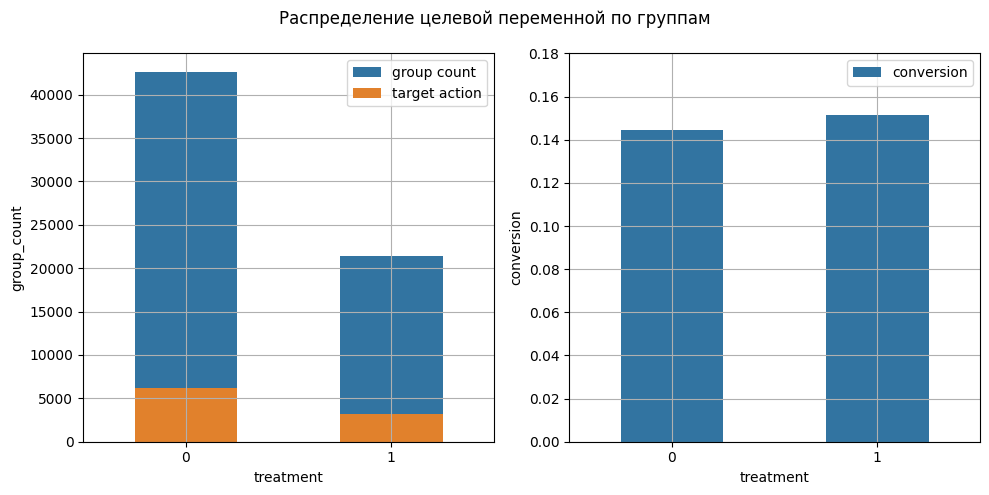

In [224]:
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

fig,axs = plt.subplots(1,2, figsize=(10,5))

sns.barplot(data=group_data, x='treatment', y='group_count', label='group count', width=0.5, ax=axs[0])
sns.barplot(data=group_data, x='treatment', y='target_action', label='target action', width=0.5, ax=axs[0])
sns.barplot(data=group_data, x='treatment', y='conversion', label='conversion', width=0.5, ax=axs[1])

axs[0].grid()
axs[1].grid()
axs[1].set_ylim((0, 0.18))
fig.suptitle('Распределение целевой переменной по группам')
fig.tight_layout()

Результат:
- имеем несбалансированные группы - контрольная группа (без воздействия) содержит в 2 раза больше записей в чем в тестовой (с воздействием)
    - надо будет учесть при выборе подхода uplift-моделирования, такой способ, который это учитывает (X- или R-learner)
- конверсия
    - в контрольной группе = 14,4%
    - в тестовой группе = 15,1%
    - прирост конверсии в тестовой группе = 0.69%
    - относительное увеличение конверсии = 4.78%

- возможно стоит более глубоко проанализировать конверсию по сегментам ..

#### Проверка на статистическую значимость увеличения конверсии между 

Проверка должна показать, что в пределах допустимой ошибки 5% (стандартное отраслевое значение), полученное увеличение конверсии неслучайно (или наоборот)

Анализ способа проверки:

- целевая переменная является дискретной бинарной величиной (воспользовалася ли пользователь промокодом на доставку или нет)
- полученное распределение в двух группах - это распределение Бернулли
    - у этого распределенрия всего два возможных значений - 0 и 1 (два "горба")
    - характеристика такого распределения - это вероятность "p" реализации значения 1
        - среднее значение = p
        - дисперсия = p(1-p)
- для такой выборки "t-test" или другие тесты (Манна-Уитни) для определения "нормального распределения" не подходят
- поэтому необходимо использовать "z-тест для двух выборок" или критерий "хи-квадрат Пирсона"
- так как данных достаточно много, z-тест согласно ЦПТ должен дать удовлетворительный способ проверки

Условие применение z-теста для соответсвия ЦПТ о выборочных средних:

- объекты в выборке независимы (независимые испытания Бернулли) 
    - можем считать, что пользователи и их поведение в Яндекс Еда независимы друг от другах
    - данные не должны содержить дублирущихся пользователей или множества действия одного пользователя - так как это будут уже не независимые испытания
- выборки должны формироваться случайно
    - TODO: надо проверить на наличие корреляции в группах между признаками и treatment 
- выборки должны содержать достаточное количество данных
    - условие Лапласа - выборка должна содержать минимум n*p >= 10 значений 
    - условие выполняется, так как данных существенно больше (тысячи) 

##### Проверим, нет ли дублированных записей (идентификторов пользователей не предоставлено) - поэтому только по значению

In [265]:
dup_count = len(data[data.duplicated(keep=False)])
print(f'duplicates count: {dup_count} ({100*dup_count/len(data):.2f}%)')

duplicates count: 7868 (12.29%)


Есть дубликаты - 7868 записей (12.29%) 
- их необходимо удалить - иначе выборка не будет удовлетворять требования ЦПТ о независимости наблюдений 

##### Очистка от дублей

In [262]:
data_cleaned = data.drop_duplicates(ignore_index=True)

In [263]:
group_data_cleaned = data_cleaned.groupby(by=['treatment']).agg(
    group_count=('target', 'count'),
    target_action=('target', 'sum'),
    conversion=('target', lambda x: round(x.mean(), 6)),
    conversion_std=('target', lambda x: round(x.std(), 6)),
    conversion_var=('target', lambda x: round(x.var(), 6))) \
    .reset_index()
display(group_data_cleaned)

convA = group_data_cleaned.query('treatment == 0')['conversion'].iat[0]
convB = group_data_cleaned.query('treatment == 1')['conversion'].iat[0]

uplift = convB-convA

print(f'Прирост конверсии в тестовой группе = {100*(uplift):.2f}%')
print(f'Относительное увеличение конверсии = {100*(uplift/convA):.2f}%')


,treatment,group_count,target_action,conversion,conversion_std,conversion_var
0,0,37826,5775,0.152673,0.359677,0.129367
1,1,19159,3069,0.160186,0.366788,0.134533


Прирост конверсии в тестовой группе = 0.75%
Относительное увеличение конверсии = 4.92%


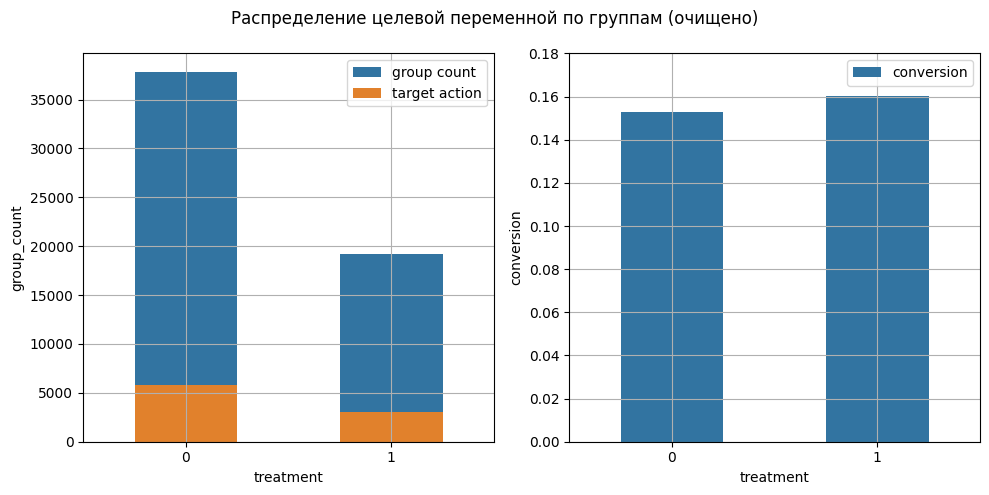

In [264]:
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

fig,axs = plt.subplots(1,2, figsize=(10,5))

sns.barplot(data=group_data_cleaned, x='treatment', y='group_count', label='group count', width=0.5, ax=axs[0])
sns.barplot(data=group_data_cleaned, x='treatment', y='target_action', label='target action', width=0.5, ax=axs[0])
sns.barplot(data=group_data_cleaned, x='treatment', y='conversion', label='conversion', width=0.5, ax=axs[1])

axs[0].grid()
axs[1].grid()
axs[1].set_ylim((0, 0.18))
fig.suptitle('Распределение целевой переменной по группам (очищено)')
fig.tight_layout()

Результат
- после очистки от дублей (7868 шт / 12.29%) значение конверсии немного выросло
    - Прирост конверсии в тестовой группе = 0.75%
    - Относительное увеличение конверсии = 4.92%

##### Реализация z-теста (z-оценки)

- имеем значения конверсии по группам на основе A/B-теста - будем считать их средними значениями выборки согласно ЦПТ
    - pA, pB - где "p" среднее значение выборки (веротность того, что target = 1)
- определяем разницу двух распределений (B-A) 
    - их среднее delta = разница средних (pB-pA) 
        - их если их среднее в точке 0 - значит выборки не отличаются друг от друга - то есть обе выборки случайны 
            - нулевая гипотеза справедлива
        - если их среднее правее точки 0, значит конверсия в тестовой группе больше чем в контрольной 
            - альтернативная гипотеза справедлива
    - их стандартное отклонение (стандартная ошибка) std_err = сумме стандартных отклонений каждой выборки
- для оценки статистической значимости получения именно такой разницы расчитыаваем z-оценку
    - z-score - это расчет разницы delta (pB-pA) в единицах величины стандартного отклонения
    - z_score = delta / std_err
- определеяем p-value - вероятноcть того, что z-оценка отклониться от нуля именно на столько единиц стандартных отклонений при условии, что нулевая гипотеза верна
    - чем сильнее z-оценка отклоняется от нуля, тем более вероятно, что нулевая гипотеза не верна 
    - если p_value больше ожидаемой ошибки 1-ого рода (alpha = 5%), то есть основания отклонить нулевую гипотезу
    - иначе оснований считать, что результаты неслучайны, нет - A/B-тест неуспешный
    - p_value = 2*(1 - CDF(z-score)) - при этом умножаем значение на 2, чтобы учесть вероятность как улучшения базового поведения, так и ухушдения
        

Функция оценки z-score и расчета p-value

In [ ]:
import scipy.stats as stat
import numpy as np

def calc_z_score(groupA, groupB):
    # данные группы A
    nA = groupA['group_count'].iat[0]
    pA = groupA['conversion'].iat[0]
    actionsA = groupA['target_action'].iat[0]
    stdA = groupA['conversion_std'].iat[0]
    varA = groupA['conversion_var'].iat[0]

    # данные группы B
    nB = groupB['group_count'].iat[0]
    pB = groupB['conversion'].iat[0]
    actionsB = groupB['target_action'].iat[0]
    stdB = groupB['conversion_std'].iat[0]
    varB = groupB['conversion_var'].iat[0]

    print(f'nA = {nA}, actionsA = {actionsA}, pA = {pA}, stdA = {stdA}, varA = {varA}')
    print(f'nB = {nB}, actionsB = {actionsB}, pB = {pB}, stdB = {stdB}, varB = {varB}')

    # расчет z-score (z-критерий Уэлча для долей)
    std_err = np.sqrt(varA/nA + varB/nB) # стандартная ошибка
    delta = (pB - pA)
    z_score = delta/std_err

    print(f'pB-pA = {100*delta:.2f}%, std_err = {std_err:.4f}, z_score = {z_score:.4f}')

    p_value = 2*(1 - stat.norm.cdf(z_score))
    print(f'p_value = {100*p_value:.2f}%')

    # границы 95% доверительного интервала
    alpha = 0.05
    z_crit = stat.norm.ppf(1 - alpha / 2)
    conf_error = z_crit * std_err
    left_bound = delta - conf_error
    right_bound = delta + conf_error
    print(f'95% доверительный интервал для разницы конверсий (pB-pA) = [{100*left_bound:+.2f}%, {100*right_bound:+.2f}%] (допустимое отклонение = {100*conf_error:.2f}%)') 

    return p_value, z_score, (left_bound, right_bound) 

Расчет для исходного датасета

In [276]:
groupA = group_data.query('treatment == 0')
groupB = group_data.query('treatment == 1')

p_value, z_score, (left_bound, right_bound) = calc_z_score(groupA, groupB)

nA = 42613, actionsA = 6156, pA = 0.144463, stdA = 0.351563, varA = 0.123596
nB = 21387, actionsB = 3238, pB = 0.1514, stdB = 0.358447, varB = 0.128484
pB-pA = 0.69%, std_err = 0.0030, z_score = 2.3242
p_value = 2.01%
95% доверительный интервал для разницы конверсий (pB-pA) = [+0.11%, +1.28%] (допустимое отклонение = 0.58%)


Расчет для очищенного датасета

In [278]:
groupA = group_data_cleaned.query('treatment == 0')
groupB = group_data_cleaned.query('treatment == 1')

p_value, z_score, (left_bound, right_bound) = calc_z_score(groupA, groupB)

nA = 37826, actionsA = 5775, pA = 0.152673, stdA = 0.359677, varA = 0.129367
nB = 19159, actionsB = 3069, pB = 0.160186, stdB = 0.366788, varB = 0.134533
pB-pA = 0.75%, std_err = 0.0032, z_score = 2.3250
p_value = 2.01%
95% доверительный интервал для разницы конверсий (pB-pA) = [+0.12%, +1.38%] (допустимое отклонение = 0.63%)


Результат
- Получена оценка p-value = 2.01% ниже допустимой alpha-ошибки 5%
- разница конверсий 0.75% входит в 95% доверительный интервал [0.12%, 1.38%], и интервал не содержит значения 0 (что означало бы возможность ухудшения конверсии)
- таким образом, можно сделать вывод, что полученное увеличение конверсии является статистически значимым, и довольно надежным (вероятность ошибки 2%) 

##### Выполним дополнительно оценку критерия "Хи-квадрат Пирсона"

Проверяет есть ли взаимосвязь между двумя группами и их конверсиями

Для расчета строится "таблица сопряжения" и вычисляется коэффициент "хи-квадрат" (chi2)
- чем более данные отличаются в группах от ожидаемых (при условии их вероятной одинаковости)
    - тем больше значение chi2 и тем меньше вероятность такого значения p-value

In [281]:
import scipy.stats as stat
import numpy as np

nA = groupA['group_count'].iat[0]
actionsA = groupA['target_action'].iat[0]

nB = groupB['group_count'].iat[0]
actionsB = groupB['target_action'].iat[0]

chi_data = [[actionsA, nA - actionsA], [actionsB, nB - actionsB]]

chi2, p_value, _, _ = stat.chi2_contingency(chi_data)

print(f'Критерий хи-квадрат = {chi2:.2f}, p_value = {100*p_value:.2f}%') 


Критерий хи-квадрат = 5.42, p_value = 1.99%


Результат
- полученное значение p_value от критерия "хи-квадрат" также < 5%, и почти совпало с p_value для z-оценки (2.01%)
- значит, статистическая значимость также подтверждается

## Построение корреляций

Сделайте вывод о корреляциях признаков друг с другом и таргетом в этой ячейке

Сделайте вывод на основе EDA в данной ячейке

## Этап 3

Обоснуйте выбор конкретной uplift модели в данной ячейке

### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую

### Обучение выбранного бейзлайна

### Расчет метрик для выбранного бейзлайна на тестовой выборке

# Обучение 2 моделей 

### Обучение модели 1

### Получение метрик по модели 1

### Обучение модели 2

### Получение метрик по модели 2

Проинтерпретируйте полученные результаты и обоснуйте выбор 1 модели в этой ячейке

# Часть 2

## Этап 1
Улучшите бейзлайн выбранной модели

#### Генерация признаков (опционально)

### Подбор гиперпараметров

In [ ]:
from optuna import create_study
from sklift.metrics import uplift_at_k

def objective(trial):
    # Дополните код для подбора гиперпараметров

    uplift_at_30 = uplift_at_k(y_test, uplift_pred, treatment_test, k=0.3, strategy='overall')
    return uplift_at_30

# Создаем и запускаем исследование
study = create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Выводим лучшие гиперпараметры
print("Best hyperparameters: ", study.best_params)
print("Best score: ", study.best_value)


## Этап 2

### Визуализация результатов

In [ ]:
from utils import custom_uplift_by_percentile

В данной ячейке сделайте вывод о качестве работы модели и проинтерпретируйте график `uplift by percentile` 

# Этап 3

In [138]:
# Класс для инференса модели
class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    """
    
    def __init__(self, model, feature_names, logger=None):
        """
        Инициализация класса.
        
        Аргументы:
            model: Обученная модель uplift
            feature_names: Список признаков для предсказания 
            logger: Объект для логирования (по умолчанию None)
        """
        self.model = model
        self.feature_names = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
        self.logger = logger
        
        if self.logger:
            self.logger.info("Модель UpliftModel инициализирована с признаками: %s", feature_names)

    def _transform_data(self, X):
        """
        Преобразование данных для модели.
        
        Аргументы:
            X: pandas.DataFrame с признаками
        """
        if self.logger:
            self.logger.debug("Преобразование входных данных размерности %s", X.shape)

        # реализуйте преобразование данных для модели,
        # если в финальной модели используются новые признаки
       

        return X
    
    def predict(self, X):
        """
        Получение предсказаний uplift.
        
        Аргументы:
            X: pandas.DataFrame с признаками
            
        Возвращает:
            numpy.array с предсказанными значениями uplift
        """
        # Проверяем, что датафрейм не пустой
        if X.empty:
            if self.logger:
                self.logger.error("Предоставлен пустой датафрейм")
            return None
            
        # Проверяем наличие пропущенных значений
        if X.isnull().any().any():
            if self.logger:
                self.logger.error("Входные данные содержат пропущенные значения")
            return [None]*len(X)
        
        if self.logger:
            self.logger.info("Выполняем предсказания для данных размерности %s", X.shape)

        # Проверяем наличие всех необходимых признаков
        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            error_msg = f"Отсутствуют признаки: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)

            return [None]*len(X)
        
        # Преобразуем данные для модели
        if self.logger:
            self.logger.debug("Начинаем преобразование данных")
        X = self._transform_data(X)
        
        # Вычисляем uplift
        if self.logger:
            self.logger.debug("Выполняем предсказания модели")
        

        # Дополните код для получения предсказаний аплифта

        
        if self.logger:
            self.logger.info("Предсказания успешно завершены")
            
        return uplift


In [126]:
model = UpliftModelInference(model= # ваш код,
                             feature_names= # ваш код)

In [ ]:
test_data = pd.DataFrame({
            'recency': [1, 2, 3],
            'history_segment': [1, 2, 3], 
            'history': [100, 200, 300],
            'mens': [1, 0, 1],
            'womens': [0, 1, 0],
            'zip_code': [1, 0, 1],
            'newbie': [0, 1, 0],
            'channel': [1, 2, 0]
        })

In [ ]:
# проверка работы класса
model.predict(test_data)